# RFUAV Experiment 4 — Kaggle Version

This notebook trains **ResNet18** on the Kaggle **Noisy Drone RF Signal Classification** dataset.

Before running:

1. Open the notebook on Kaggle.
2. Click **Add Input**.
3. Add the dataset: `sgluege/noisy-drone-rf-signal-classification`.
4. In notebook settings, set **Accelerator → GPU**.

The notebook uses:

```text
/kaggle/input/    # read-only dataset files
/kaggle/working/  # saved models, plots, CSV results
```

The model input is:

```text
x_spec: [number_of_samples, 2, 128, 128]
```


## 1. Check GPU, RAM, and disk

Run this first to confirm whether Kaggle has a GPU attached and enough RAM/disk space.

In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. On Kaggle: Settings → Accelerator → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /kaggle/working


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       953Mi        27Gi       1.0Mi       3.3Gi        29Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  204K   20G   1% /kaggle/working


## 2. Locate the Kaggle dataset

This replaces the old Colab/Kaggle-API download cells. On Kaggle, use **Add Input** instead of downloading the dataset inside the notebook.

In [2]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Find dataset.pt automatically so the notebook still works if Kaggle changes the mounted folder name.
candidates = list(KAGGLE_INPUT.rglob("dataset.pt"))
if not candidates:
    raise FileNotFoundError(
        "Could not find dataset.pt under /kaggle/input. "
        "Click Add Input and attach sgluege/noisy-drone-rf-signal-classification first."
    )

DATA_PATH = candidates[0]
DATA_DIR = DATA_PATH.parent

class_stats_path = DATA_DIR / "class_stats.csv"
snr_stats_path = DATA_DIR / "SNR_stats.csv"

print("DATA_DIR:", DATA_DIR)
print("DATA_PATH:", DATA_PATH)
print("File size GB:", DATA_PATH.stat().st_size / 1024**3)
print("SAVE_DIR:", SAVE_DIR)

print("\nFiles in DATA_DIR:")
for p in sorted(DATA_DIR.iterdir()):
    print("-", p.name)


DATA_DIR: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification
DATA_PATH: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt
File size GB: 24.099373045377433
SAVE_DIR: /kaggle/working/noisy_drone_resnet18_spec_balanced

Files in DATA_DIR:
- SNR_stats.csv
- class_stats.csv
- dataset.pt


## 3. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [3]:
import pandas as pd

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 4. Safely load `dataset.pt` with memory mapping

`dataset.pt` is large, so normal `torch.load()` can use too much RAM. This notebook uses `mmap=True` to avoid loading everything into memory at once.

In [4]:
import torch

print("Before loading:")
!free -h

data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


Before loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       987Mi        27Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       991Mi        27Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B


## 5. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

In [5]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

# Set QUICK_TEST = True for a short pipeline test before using GPU quota on a full run.
QUICK_TEST = False

if QUICK_TEST:
    train_per_class = 300
    valid_per_class = 100
else:
    train_per_class = 1700
    valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 11900
Valid samples: 2800
DJI: train=1700, valid=400
FutabaT14: train=1700, valid=400
FutabaT7: train=1700, valid=400
Graupner: train=1700, valid=400
Noise: train=1700, valid=400
Taranis: train=1700, valid=400
Turnigy: train=1700, valid=400


## 6. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [6]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Kaggle + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 7. Define ResNet18 for 2-channel RF spectrograms

Normal ResNet18 expects RGB images with shape:

```text
[batch, 3, height, width]
```

This dataset uses RF spectrogram tensors with shape:

```text
[batch, 2, 128, 128]
```

So we modify the first convolution layer to accept 2 input channels and change the final fully connected layer to output 7 classes.

For this RF dataset, we use `weights=None` because ImageNet pretrained weights are designed for natural RGB images, not 2-channel RF spectrograms.


In [7]:
data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32


In [8]:
import torch.nn as nn
from torchvision import models

class ResNet18RFSpec(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Start with a standard ResNet18 architecture.
        # weights=None avoids RGB ImageNet pretrained weights.
        self.model = models.resnet18(weights=None)

        # Original ResNet18 first layer expects 3-channel RGB images.
        # Our RF spectrogram tensors have 2 channels, so change 3 -> 2.
        self.model.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Replace the final classifier for 7 drone/noise classes.
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Quick shape test before training.
model_test = ResNet18RFSpec(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 8. Set Kaggle output folder for saving results

Kaggle outputs should be saved in `/kaggle/working/` so they appear in the notebook Output section.


In [9]:
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Save directory:", SAVE_DIR)


Save directory: /kaggle/working/noisy_drone_resnet18_spec_balanced


## 9. Train ResNet18 with learning-rate scheduling

This trains ResNet18 on the balanced spectrogram subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`

This version uses:

- `AdamW` optimizer
- `CosineAnnealingLR` scheduler

Start with `batch_size = 64`. If Kaggle gives a CUDA out-of-memory error, go back to the DataLoader cell and reduce `batch_size` to `32`.

In [10]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

SPEC_SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler")
SPEC_SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR = SPEC_SAVE_DIR  # keep this name for the existing evaluation cells below

# If True, train only a tiny version to check that the notebook runs.
# Set QUICK_TEST = False in the balanced subset cell for a real 20-epoch run.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Saving spectrogram model to:", SPEC_SAVE_DIR)

model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 2 if QUICK_TEST else 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), SPEC_SAVE_DIR / "best.pt")
        print("Saved best model.")

torch.save(model.state_dict(), SPEC_SAVE_DIR / "last.pt")

history_df = pd.DataFrame(history)
history_df.to_csv(SPEC_SAVE_DIR / "history.csv", index=False)

print("Finished spectrogram ResNet18 training.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SPEC_SAVE_DIR)


Using device: cuda
Saving spectrogram model to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler
Epoch 1/20


Validation: 100%|██████████| 44/44 [00:06<00:00,  6.81it/s]


Train Loss: 1.4563
Train Acc : 0.4458
Valid Loss: 1.0038
Valid Acc : 0.6450
Learning Rate: 0.000994
Saved best model.
Epoch 2/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 50.79it/s]


Train Loss: 0.8147
Train Acc : 0.7120
Valid Loss: 0.7682
Valid Acc : 0.7207
Learning Rate: 0.000976
Saved best model.
Epoch 3/20


...

Train Loss: 0.0011
Train Acc : 1.0000
Valid Loss: 0.7823
Valid Acc : 0.8557
Learning Rate: 0.000024
Saved best model.
Epoch 19/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.38it/s]


Train Loss: 0.0012
Train Acc : 0.9999
Valid Loss: 0.8426
Valid Acc : 0.8471
Learning Rate: 0.000006
Epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.19it/s]


Train Loss: 0.0011
Train Acc : 0.9999
Valid Loss: 0.7941
Valid Acc : 0.8493
Learning Rate: 0.000000
Finished spectrogram ResNet18 training.
Best valid accuracy: 0.8557142857142858
Saved to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler


## 10. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.456327,0.445798,1.003812,0.645000,0.000994
1,2,0.814679,0.712017,0.768241,0.720714,0.000976
2,3,0.602184,0.793193,0.749569,0.743214,0.000946
3,4,0.472566,0.837731,0.550202,0.801071,0.000905
4,5,0.389073,0.866471,0.652308,0.797143,0.000854
5,6,0.341243,0.882857,0.510246,0.830000,0.000794
6,7,0.258779,0.912605,0.517991,0.837143,0.000727
7,8,0.209671,0.927059,0.606361,0.812143,0.000655
8,9,0.145678,0.950588,0.651867,0.832143,0.000578
9,10,0.093400,0.966723,0.767132,0.806786,0.000500


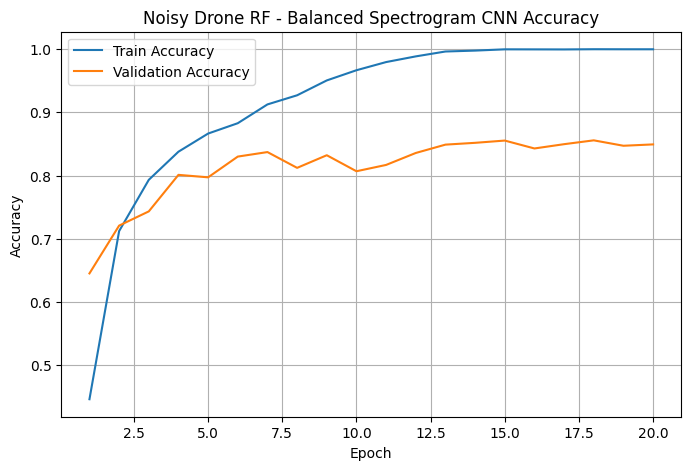

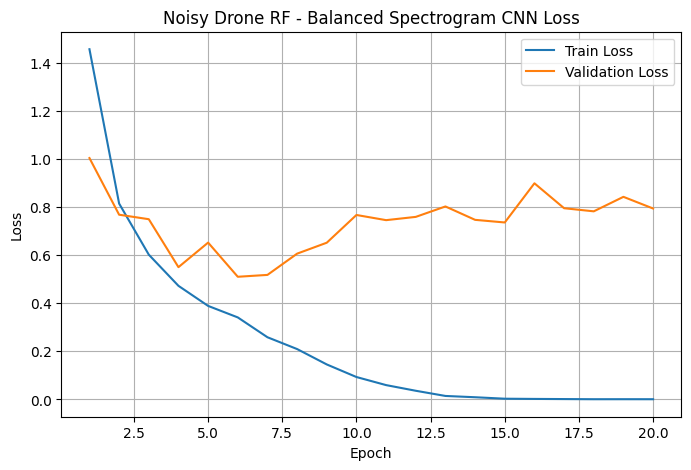

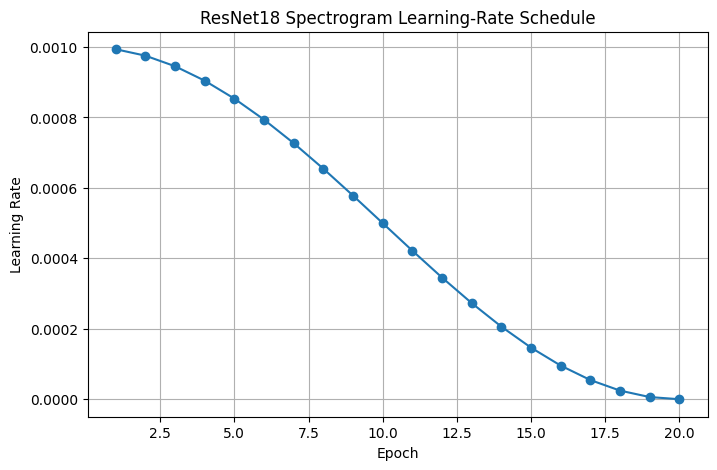

In [11]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

if "lr" in history_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["lr"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("ResNet18 Spectrogram Learning-Rate Schedule")
    plt.grid(True)
    plt.show()


## 11. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/best.pt
              precision    recall  f1-score   support

         DJI       0.85      0.90      0.87       400
   FutabaT14       0.90      0.83      0.87       400
    FutabaT7       0.83      0.84      0.84       400
    Graupner       0.93      0.91      0.92       400
       Noise       0.72      0.78      0.75       400
     Taranis       0.96      0.92      0.94       400
     Turnigy       0.81      0.81      0.81       400

    accuracy                           0.86      2800
   macro avg       0.86      0.86      0.86      2800
weighted avg       0.86      0.86      0.86      2800



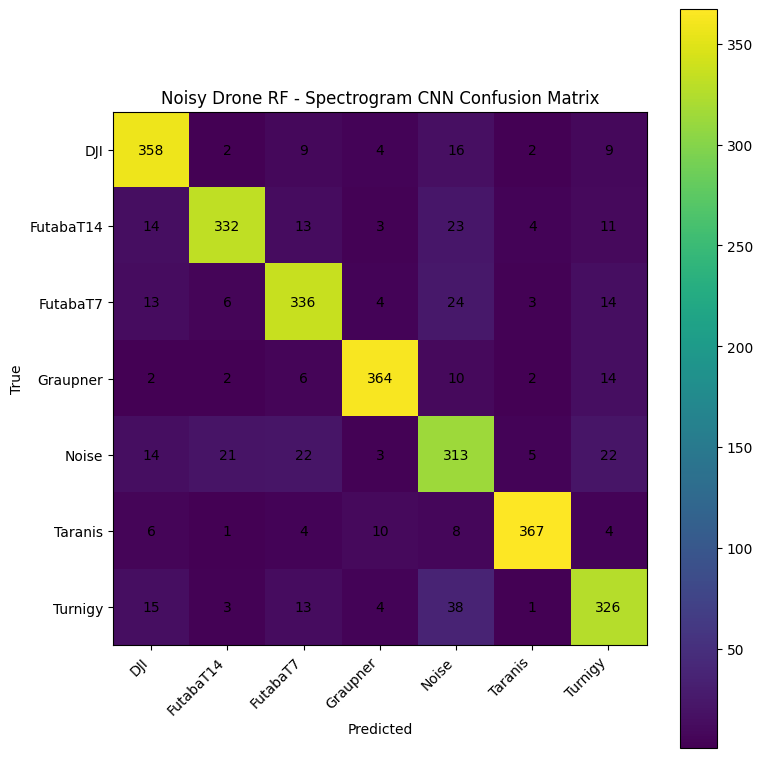

Saved confusion matrix to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix.png


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 12. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.214953
1,-18,0.436170
2,-16,0.533981
3,-14,0.603175
4,-12,0.676471
5,-10,0.779070
6,-8,0.913462
7,-6,0.911765
8,-4,0.918367
9,-2,0.967213


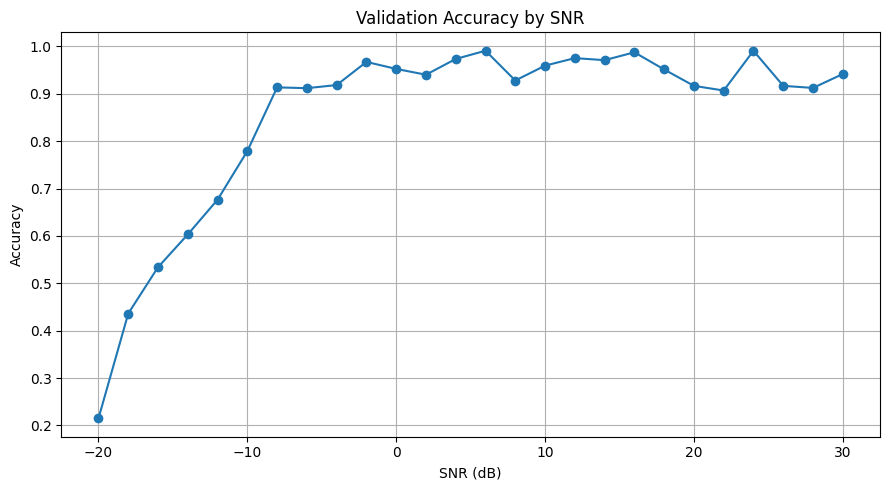

Saved SNR accuracy plot to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/accuracy_by_snr.png


In [13]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)


## 13. Confusion matrices by SNR group

The overall confusion matrix hides where the model fails. This section splits the validation set into low, medium, and high SNR groups, then creates a separate confusion matrix for each group.

Suggested groups:

```text
Low SNR:    -20 to -10 dB
Medium SNR: -8 to 4 dB
High SNR:    6 to 30 dB
```

This helps show whether errors such as `Turnigy → Noise` mainly happen when the RF signal is weak.


low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.5356

Classification report:
              precision    recall  f1-score   support

         DJI       0.49      0.54      0.51        81
   FutabaT14       0.55      0.30      0.39        88
    FutabaT7       0.48      0.38      0.42        88
    Graupner       0.74      0.61      0.67        87
       Noise       0.39      0.78      0.52        87
     Taranis       0.86      0.69      0.76        86
     Turnigy       0.50      0.48      0.49       101

    accuracy                           0.54       618
   macro avg       0.57      0.54      0.54       618
weighted avg       0.57      0.54      0.53       618



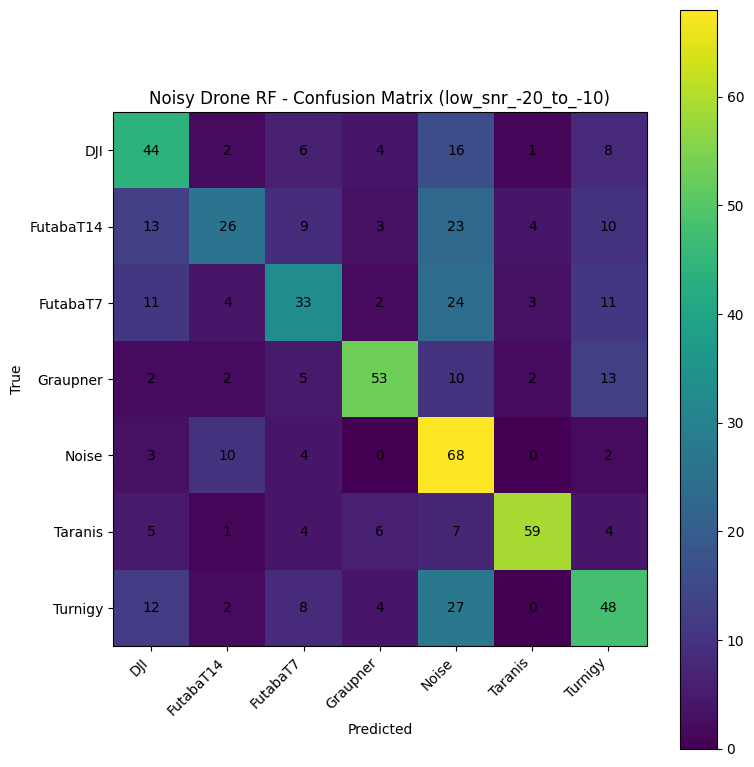

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_low_snr_-20_to_-10.png
medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.9409

Classification report:
              precision    recall  f1-score   support

         DJI       0.94      0.97      0.96       112
   FutabaT14       0.96      0.96      0.96       112
    FutabaT7       0.91      0.95      0.93       106
    Graupner       0.98      0.99      0.99       119
       Noise       0.90      0.87      0.88       104
     Taranis       1.00      0.97      0.99       111
     Turnigy       0.88      0.85      0.86        97

    accuracy                           0.94       761
   macro avg       0.94      0.94      0.94       761
weighted avg       0.94      0.94      0.94       761



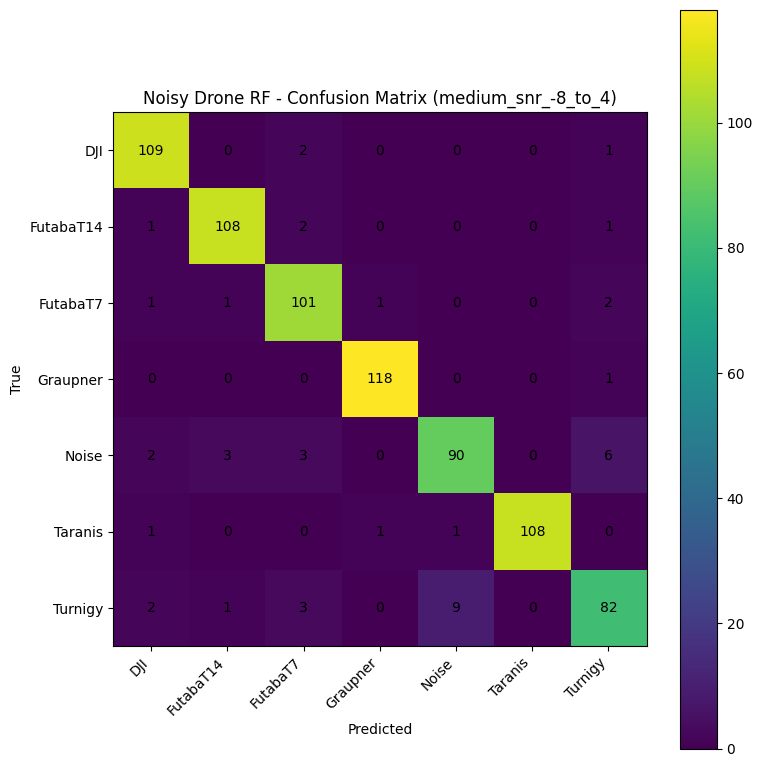

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_medium_snr_-8_to_4.png
high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9493

Classification report:
              precision    recall  f1-score   support

         DJI       0.95      0.99      0.97       207
   FutabaT14       0.96      0.99      0.97       200
    FutabaT7       0.91      0.98      0.94       206
    Graupner       0.96      0.99      0.98       194
       Noise       0.99      0.74      0.85       209
     Taranis       0.97      0.99      0.98       203
     Turnigy       0.93      0.97      0.95       202

    accuracy                           0.95      1421
   macro avg       0.95      0.95      0.95      1421
weighted avg       0.95      0.95      0.95      1421



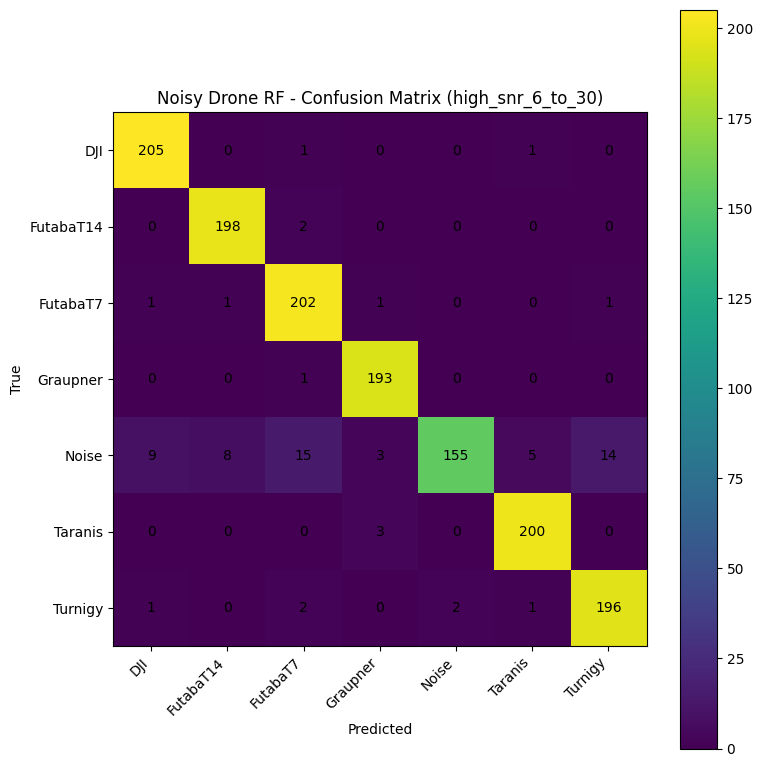

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/confusion_matrix_high_snr_6_to_30.png


,group,snr_min,snr_max,samples,accuracy
0,low_snr_-20_to_-10,-20,-10,618,0.535599
1,medium_snr_-8_to_4,-8,4,761,0.940867
2,high_snr_6_to_30,6,30,1421,0.949331


Saved SNR group summary to: /kaggle/working/noisy_drone_resnet18_spec_balanced_scheduler/snr_group_summary.csv


In [14]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# This cell expects these variables from the evaluation cell:
# all_labels, all_preds, all_snrs, class_names, SAVE_DIR

results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})

results_df["correct"] = results_df["label"] == results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

def plot_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    return cm

snr_summary_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    if len(subset) == 0:
        print(f"No validation samples found for {group_name}")
        continue

    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"{group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR, f"confusion_matrix_{group_name}.png")
    cm_group = plot_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - Confusion Matrix ({group_name})",
        save_path
    )
    print("Saved:", save_path)

    snr_summary_rows.append({
        "group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "samples": len(subset),
        "accuracy": acc,
    })

snr_group_summary = pd.DataFrame(snr_summary_rows)
display(snr_group_summary)

summary_path = os.path.join(SAVE_DIR, "snr_group_summary.csv")
snr_group_summary.to_csv(summary_path, index=False)
print("Saved SNR group summary to:", summary_path)


---

# 14. IQ-based model experiment

The previous experiment used `x_spec`, a 2-channel spectrogram tensor.

This section uses the raw I/Q tensor directly:

```text
x_iq: [number_of_samples, 2, 16384]
```

The model is a 1D CNN with `Conv1d(2, ...)`, because the two channels represent I and Q. This experiment also uses `AdamW` and `CosineAnnealingLR`.


## 14.1 Build Dataset and DataLoaders for `x_iq`

Each sample is normalized independently. This helps the 1D CNN focus on waveform shape instead of absolute amplitude scale.


In [15]:
class NoisyDroneIQDataset(Dataset):
    def __init__(self, data, indices, normalize=True):
        self.x_iq = data["x_iq"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices
        self.normalize = normalize

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])

        x = self.x_iq[real_idx]   # [2, 16384]
        label = self.y[real_idx]
        snr = self.snr[real_idx]

        if self.normalize:
            x = (x - x.mean()) / (x.std() + 1e-8)

        return x, label, snr

# Raw IQ sequences are larger than spectrogram tensors, so reduce this if GPU memory is tight.
iq_batch_size = 64

train_iq_dataset = NoisyDroneIQDataset(data, train_indices, normalize=True)
valid_iq_dataset = NoisyDroneIQDataset(data, valid_indices, normalize=True)

train_iq_loader = DataLoader(
    train_iq_dataset,
    batch_size=iq_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_iq_loader = DataLoader(
    valid_iq_dataset,
    batch_size=iq_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_iq_batch, y_iq_batch, snr_iq_batch = next(iter(train_iq_loader))

print("IQ batch:", x_iq_batch.shape)
print("Label batch:", y_iq_batch.shape)
print("SNR batch:", snr_iq_batch.shape)
print("IQ dtype:", x_iq_batch.dtype)


IQ batch: torch.Size([64, 2, 16384])
Label batch: torch.Size([64])
SNR batch: torch.Size([64])
IQ dtype: torch.float32


## 14.2 Define IQ 1D CNN

This model learns directly from the I/Q time sequence instead of the spectrogram image.


In [16]:
class IQ1DCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Quick shape test before training.
model_test = IQ1DCNN(num_classes=len(class_names))
with torch.no_grad():
    out = model_test(x_iq_batch[:2])

print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 14.3 Train IQ 1D CNN with learning-rate scheduling

This uses the same balanced indices as the spectrogram experiment, so the two results are comparable.


In [17]:
IQ_SAVE_DIR = Path("/kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler")
IQ_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Using device:", device)
print("Saving IQ model to:", IQ_SAVE_DIR)

model_iq = IQ1DCNN(num_classes=len(class_names)).to(device)
criterion_iq = nn.CrossEntropyLoss()

optimizer_iq = optim.AdamW(
    model_iq.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

iq_epochs = 2 if QUICK_TEST else 20
scheduler_iq = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_iq,
    T_max=iq_epochs
)

history_iq = []
best_iq_acc = 0.0

for epoch in range(iq_epochs):
    print("=" * 60)
    print(f"IQ Epoch {epoch + 1}/{iq_epochs}")

    model_iq.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_iq_loader, desc="IQ Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_iq.zero_grad()
        outputs = model_iq(x)
        loss = criterion_iq(outputs, labels)
        loss.backward()
        optimizer_iq.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model_iq.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_iq_loader, desc="IQ Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_iq(x)
            loss = criterion_iq(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    scheduler_iq.step()
    current_lr = optimizer_iq.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    history_iq.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "lr": current_lr,
    })

    if valid_acc > best_iq_acc:
        best_iq_acc = valid_acc
        torch.save(model_iq.state_dict(), IQ_SAVE_DIR / "best.pt")
        print("Saved best IQ model.")

torch.save(model_iq.state_dict(), IQ_SAVE_DIR / "last.pt")

history_iq_df = pd.DataFrame(history_iq)
history_iq_df.to_csv(IQ_SAVE_DIR / "history.csv", index=False)

print("Finished IQ 1D CNN training.")
print("Best IQ valid accuracy:", best_iq_acc)
print("Saved to:", IQ_SAVE_DIR)


Using device: cuda
Saving IQ model to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler
IQ Epoch 1/20


IQ Validation: 100%|██████████| 44/44 [00:06<00:00,  6.42it/s]


Train Loss: 1.3161
Train Acc : 0.5182
Valid Loss: 2.0460
Valid Acc : 0.4075
Learning Rate: 0.000994
Saved best IQ model.
IQ Epoch 2/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 53.45it/s]


Train Loss: 1.0114
Train Acc : 0.6399
Valid Loss: 2.1351
Valid Acc : 0.4321
Learning Rate: 0.000976
Saved best IQ model.
IQ Epoch 3/20


...

Train Loss: 0.2135
Train Acc : 0.9498
Valid Loss: 0.8572
Valid Acc : 0.7029
Learning Rate: 0.000024
IQ Epoch 19/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 53.91it/s]


Train Loss: 0.2039
Train Acc : 0.9522
Valid Loss: 0.8069
Valid Acc : 0.7275
Learning Rate: 0.000006
IQ Epoch 20/20


IQ Validation: 100%|██████████| 44/44 [00:00<00:00, 52.42it/s]

Train Loss: 0.1970
Train Acc : 0.9560
Valid Loss: 0.7964
Valid Acc : 0.7314
Learning Rate: 0.000000
Finished IQ 1D CNN training.
Best IQ valid accuracy: 0.7335714285714285
Saved to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler


## 14.4 Plot IQ training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.316148,0.518151,2.046041,0.407500,0.000994
1,2,1.011417,0.639916,2.135069,0.432143,0.000976
2,3,0.906387,0.682605,1.443181,0.523929,0.000946
3,4,0.838382,0.704286,1.139808,0.640714,0.000905
4,5,0.820224,0.711597,3.204698,0.503929,0.000854
5,6,0.749214,0.736134,4.164918,0.460714,0.000794
6,7,0.711308,0.746807,1.798763,0.521071,0.000727
7,8,0.657142,0.770420,2.338883,0.542857,0.000655
8,9,0.596733,0.790000,1.976787,0.642500,0.000578
9,10,0.541095,0.817143,2.510116,0.583214,0.000500


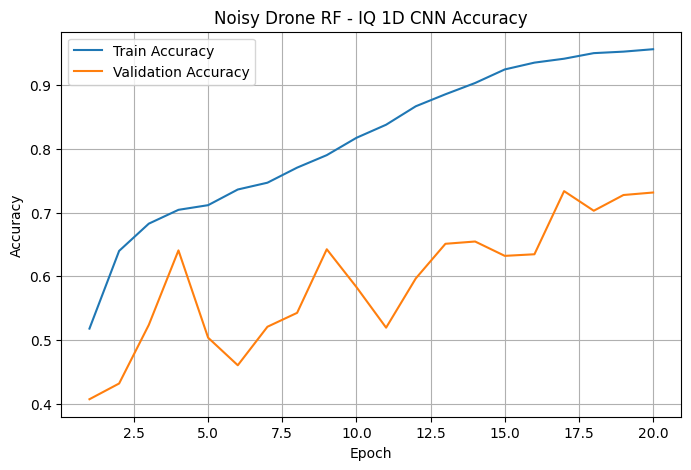

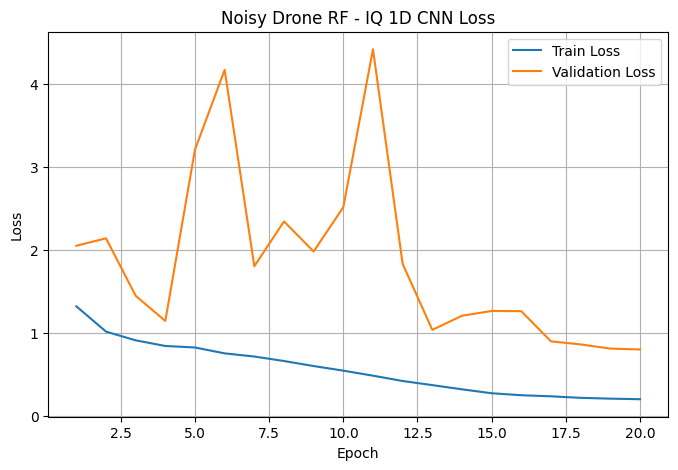

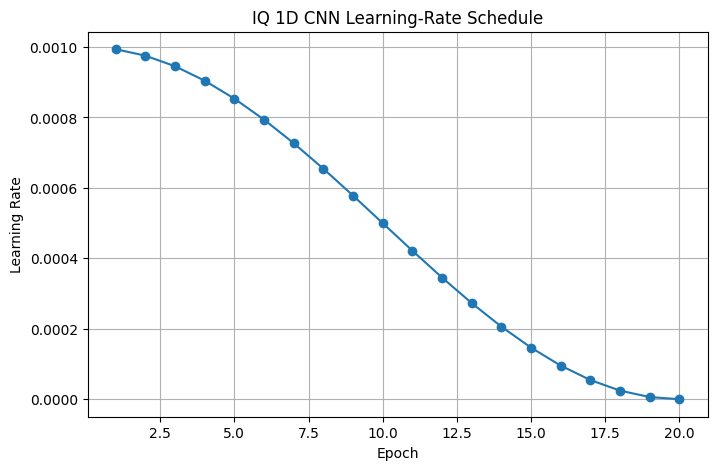

In [18]:
history_iq_path = IQ_SAVE_DIR / "history.csv"
history_iq_df = pd.read_csv(history_iq_path)
display(history_iq_df)

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["train_acc"], label="Train Accuracy")
plt.plot(history_iq_df["epoch"], history_iq_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - IQ 1D CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["train_loss"], label="Train Loss")
plt.plot(history_iq_df["epoch"], history_iq_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - IQ 1D CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_iq_df["epoch"], history_iq_df["lr"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("IQ 1D CNN Learning-Rate Schedule")
plt.grid(True)
plt.show()


## 14.5 Evaluate IQ 1D CNN

This creates the same outputs as the spectrogram experiment: classification report, confusion matrix, and saved prediction table.


Loaded best IQ model: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/best.pt
              precision    recall  f1-score   support

         DJI       0.97      0.67      0.79       400
   FutabaT14       0.90      0.68      0.77       400
    FutabaT7       0.94      0.66      0.77       400
    Graupner       0.93      0.75      0.83       400
       Noise       0.38      0.93      0.54       400
     Taranis       0.93      0.82      0.87       400
     Turnigy       0.88      0.62      0.73       400

    accuracy                           0.73      2800
   macro avg       0.85      0.73      0.76      2800
weighted avg       0.85      0.73      0.76      2800



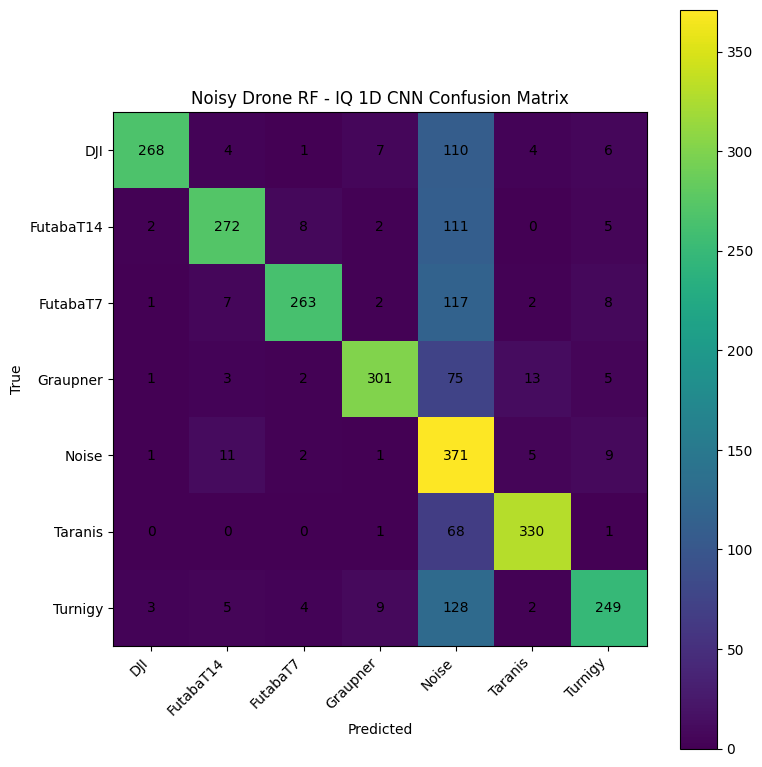

Saved IQ confusion matrix to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_1dcnn.png
Saved IQ prediction table to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/valid_predictions.csv


In [19]:
# Load best IQ model before evaluation.
best_iq_path = IQ_SAVE_DIR / "best.pt"
if best_iq_path.exists():
    model_iq.load_state_dict(torch.load(best_iq_path, map_location=device))
    print("Loaded best IQ model:", best_iq_path)

model_iq.eval()
all_iq_preds = []
all_iq_labels = []
all_iq_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_iq_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_iq(x)
        preds = outputs.argmax(dim=1)

        all_iq_preds.extend(preds.cpu().numpy())
        all_iq_labels.extend(labels.cpu().numpy())
        all_iq_snrs.extend(snrs.cpu().numpy())

print(classification_report(
    all_iq_labels,
    all_iq_preds,
    target_names=class_names
))

cm_iq = confusion_matrix(all_iq_labels, all_iq_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm_iq)
plt.title("Noisy Drone RF - IQ 1D CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_iq[i, j], ha="center", va="center")

plt.tight_layout()
cm_iq_path = IQ_SAVE_DIR / "confusion_matrix_iq_1dcnn.png"
plt.savefig(cm_iq_path, dpi=200)
plt.show()

print("Saved IQ confusion matrix to:", cm_iq_path)

results_iq_df = pd.DataFrame({
    "label": all_iq_labels,
    "pred": all_iq_preds,
    "snr": all_iq_snrs,
})
results_iq_df["correct"] = results_iq_df["label"] == results_iq_df["pred"]
results_iq_df.to_csv(IQ_SAVE_DIR / "valid_predictions.csv", index=False)
print("Saved IQ prediction table to:", IQ_SAVE_DIR / "valid_predictions.csv")


## 14.6 IQ accuracy by SNR


,SNR,accuracy
0,-20,0.112150
1,-18,0.191489
2,-16,0.203883
3,-14,0.238095
4,-12,0.294118
5,-10,0.290698
6,-8,0.365385
7,-6,0.578431
8,-4,0.602041
9,-2,0.704918


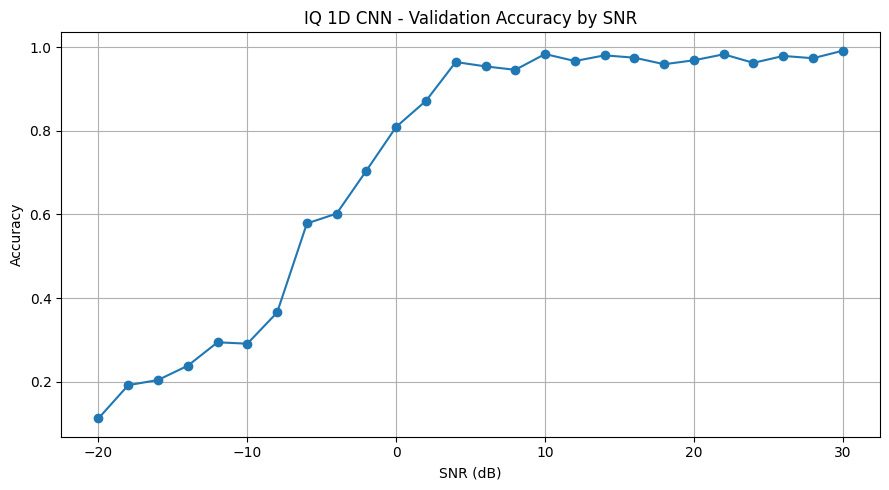

Saved IQ SNR accuracy plot to: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/accuracy_by_snr_iq_1dcnn.png


In [20]:
snr_iq_acc = results_iq_df.groupby("snr")["correct"].mean().reset_index()
snr_iq_acc.columns = ["SNR", "accuracy"]
display(snr_iq_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_iq_acc["SNR"], snr_iq_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("IQ 1D CNN - Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_iq_path = IQ_SAVE_DIR / "accuracy_by_snr_iq_1dcnn.png"
plt.savefig(snr_iq_path, dpi=200)
plt.show()

print("Saved IQ SNR accuracy plot to:", snr_iq_path)


## 14.7 IQ confusion matrices by SNR group

This lets you compare whether the IQ model handles low-SNR samples better or worse than the spectrogram ResNet18 model.


low_snr_-20_to_-10
Samples: 618
Accuracy: 0.22006472491909385
              precision    recall  f1-score   support

         DJI       0.33      0.02      0.05        81
   FutabaT14       0.21      0.03      0.06        88
    FutabaT7       0.00      0.00      0.00        88
    Graupner       0.64      0.21      0.31        87
       Noise       0.16      0.95      0.28        87
     Taranis       0.81      0.30      0.44        86
     Turnigy       0.19      0.04      0.07       101

    accuracy                           0.22       618
   macro avg       0.34      0.22      0.17       618
weighted avg       0.33      0.22      0.17       618



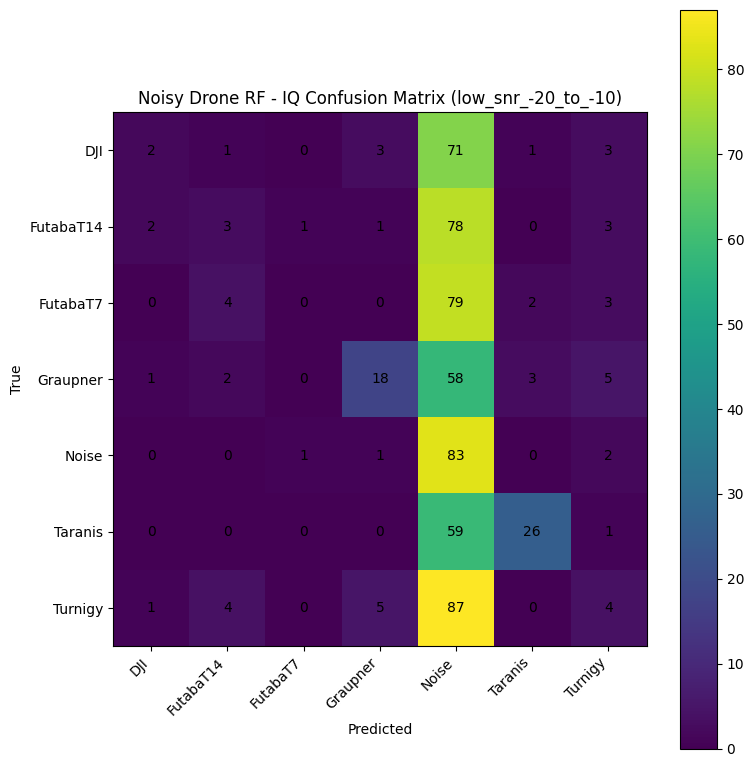

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_low_snr_-20_to_-10.png
medium_snr_-8_to_4
Samples: 761
Accuracy: 0.7069645203679369
              precision    recall  f1-score   support

         DJI       0.94      0.59      0.73       112
   FutabaT14       0.88      0.64      0.74       112
    FutabaT7       0.86      0.60      0.71       106
    Graupner       0.89      0.75      0.81       119
       Noise       0.37      0.92      0.53       104
     Taranis       0.86      0.92      0.89       111
     Turnigy       0.86      0.51      0.64        97

    accuracy                           0.71       761
   macro avg       0.81      0.70      0.72       761
weighted avg       0.81      0.71      0.73       761



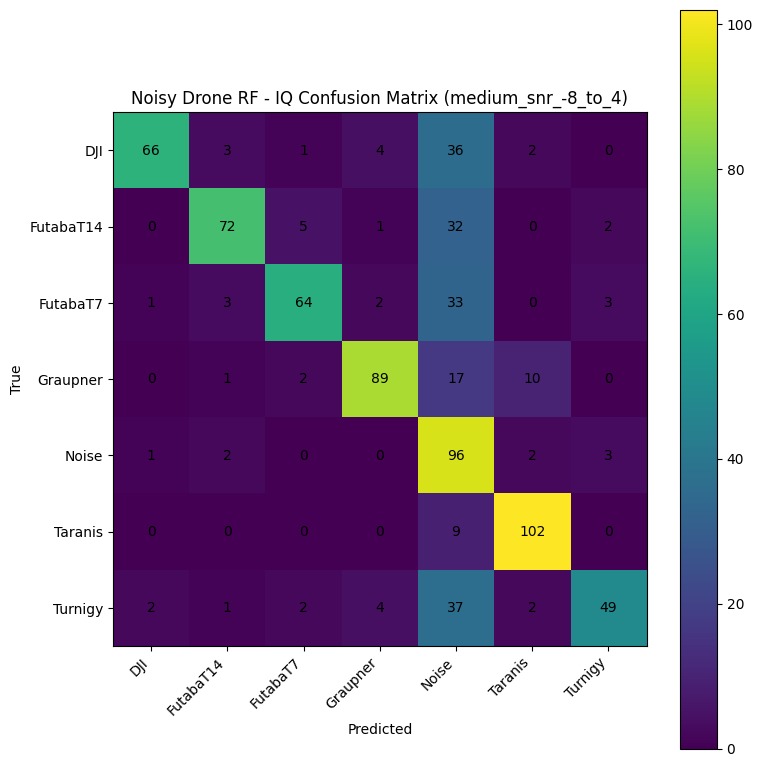

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_medium_snr_-8_to_4.png
high_snr_6_to_30
Samples: 1421
Accuracy: 0.9711470795214637
              precision    recall  f1-score   support

         DJI       1.00      0.97      0.98       207
   FutabaT14       0.96      0.98      0.97       200
    FutabaT7       0.98      0.97      0.97       206
    Graupner       0.99      1.00      1.00       194
       Noise       0.94      0.92      0.93       209
     Taranis       0.98      1.00      0.99       203
     Turnigy       0.96      0.97      0.96       202

    accuracy                           0.97      1421
   macro avg       0.97      0.97      0.97      1421
weighted avg       0.97      0.97      0.97      1421



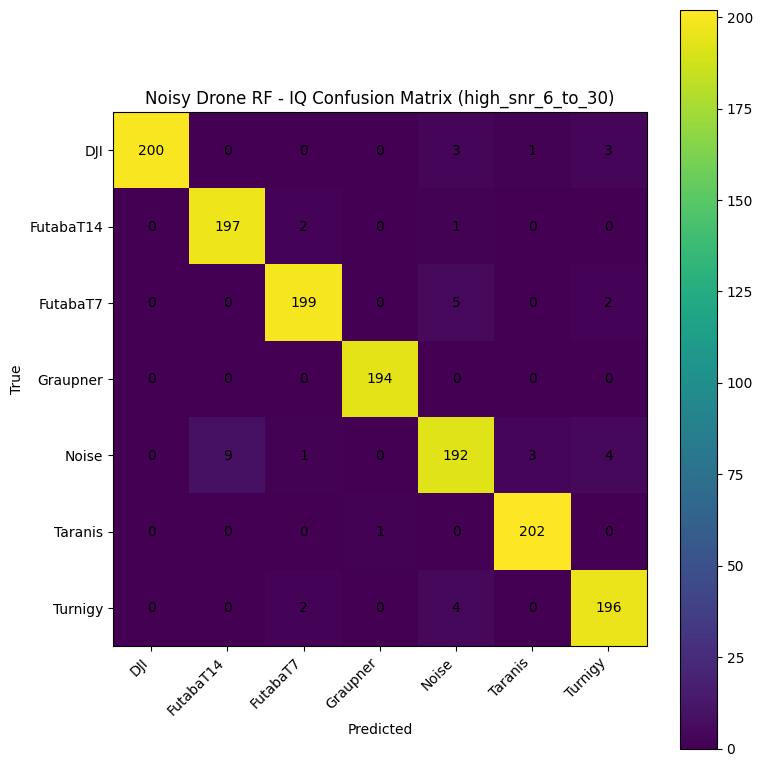

Saved: /kaggle/working/noisy_drone_iq_1dcnn_balanced_scheduler/confusion_matrix_iq_high_snr_6_to_30.png


In [21]:
def plot_iq_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved:", save_path)
    return cm

for group_name, (low, high) in snr_groups.items():
    subset = results_iq_df[(results_iq_df["snr"] >= low) & (results_iq_df["snr"] <= high)]

    print("=" * 60)
    print(group_name)
    print("Samples:", len(subset))

    if len(subset) == 0:
        print("No samples in this SNR group.")
        continue

    print("Accuracy:", subset["correct"].mean())
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    ))

    save_path = IQ_SAVE_DIR / f"confusion_matrix_iq_{group_name}.png"
    plot_iq_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - IQ Confusion Matrix ({group_name})",
        save_path
    )


---

# 15. Compare spectrogram ResNet18 vs IQ 1D CNN

Use this section after both models have finished training and evaluation. The most important comparison is not only overall validation accuracy, but also low-SNR behavior.


In [22]:
comparison_rows = []

# Spectrogram model metrics from results_df
if "results_df" in globals():
    comparison_rows.append({
        "model": "ResNet18 on x_spec",
        "overall_accuracy": results_df["correct"].mean(),
        "low_snr_accuracy": results_df[(results_df["snr"] >= -20) & (results_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_df[(results_df["snr"] >= -8) & (results_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_df[(results_df["snr"] >= 6) & (results_df["snr"] <= 30)]["correct"].mean(),
    })

# IQ model metrics from results_iq_df
if "results_iq_df" in globals():
    comparison_rows.append({
        "model": "1D CNN on x_iq",
        "overall_accuracy": results_iq_df["correct"].mean(),
        "low_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -20) & (results_iq_df["snr"] <= -10)]["correct"].mean(),
        "medium_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= -8) & (results_iq_df["snr"] <= 4)]["correct"].mean(),
        "high_snr_accuracy": results_iq_df[(results_iq_df["snr"] >= 6) & (results_iq_df["snr"] <= 30)]["correct"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_df.to_csv(Path("/kaggle/working/model_comparison_spec_vs_iq.csv"), index=False)
print("Saved comparison table to /kaggle/working/model_comparison_spec_vs_iq.csv")


,model,overall_accuracy,low_snr_accuracy,medium_snr_accuracy,high_snr_accuracy
0,ResNet18 on x_spec,0.855714,0.535599,0.940867,0.949331
1,1D CNN on x_iq,0.733571,0.220065,0.706965,0.971147


Saved comparison table to /kaggle/working/model_comparison_spec_vs_iq.csv
